0. các thư viện sử dụng không sử dụng pandas


In [3]:
import numpy as np
import matplotlib.pyplot as plt # thư viện dùng vẽ biểu đồ
# Cấu hình in ấn cho đẹp
np.set_printoptions(precision=2, suppress=True)

1. đọc dữ liệu từ file csv

In [1]:
# --- 1. ĐỌC DỮ LIỆU TỪ FILE ---




# --- 1. ĐỌC DỮ LIỆU (Checklist 1) ---
print("--- 1. ĐỌC DỮ LIỆU ---")
try:
    # skip_header=1 để bỏ qua dòng tiêu đề
    data1 = np.genfromtxt(r"D:\OneDrive\Máy tính\LOP_DHKLN18A2HN_NHOM_03_CASE9\LOP_DHKLN18A2HN_NHOM_03_CASE9\NHOM3_CASE9\semester1_scores.csv", delimiter=',', skip_header=1)
    data2 = np.genfromtxt(r"D:\OneDrive\Máy tính\LOP_DHKLN18A2HN_NHOM_03_CASE9\LOP_DHKLN18A2HN_NHOM_03_CASE9\NHOM3_CASE9\semester2_scores.csv", delimiter=',', skip_header=1)
    print(">> Đã đọc file thành công.")
except:
    print("!! Lỗi: Không tìm thấy file csv. Hãy đảm bảo file nằm cùng thư mục.")

--- 1. ĐỌC DỮ LIỆU ---
!! Lỗi: Không tìm thấy file csv. Hãy đảm bảo file nằm cùng thư mục.


2. tách dữ liệu

In [5]:
# --- 2. TÁCH CỘT (Checklist 2) ---
# Cấu trúc: student_id, midterm, final, attendance
ids = data1[:, 0].astype(int)
mid1, fin1, att1 = data1[:, 1], data1[:, 2], data1[:, 3]
mid2, fin2, att2 = data2[:, 1], data2[:, 2], data2[:, 3]

3. tính điểm tổng hợp
Công thức tính điểm$$Total = 0.3 \times Midterm + 0.5 \times Final + 0.2 \times Attendance$$

In [8]:
# --- 3. TÍNH ĐIỂM TỔNG HỢP (Mục tiêu 3) ---
total1 = 0.3 * mid1 + 0.5 * fin1 + 0.2 * att1
total2 = 0.3 * mid2 + 0.5 * fin2 + 0.2 * att2

4. Kiểm tra dtype, shape; in 5 giá trị đầu/cuối.

In [12]:
# --- 4. KIỂM TRA DTYPE + SHAPE (Checklist 3) ---
print(f"\n--- 4. KIỂM TRA DỮ LIỆU ---")
# Kiểm tra HK1
print(f"Shape HK1: {data1.shape}, Dtype: {data1.dtype}")
print(f"5 dòng đầu HK1:\n{data1[:5]}")

# [BỔ SUNG] Kiểm tra HK2
print(f"Shape HK2: {data2.shape}, Dtype: {data2.dtype}")
print(f"5 dòng đầu HK2:\n{data2[:5]}")


--- 4. KIỂM TRA DỮ LIỆU ---
Shape HK1: (150, 4), Dtype: float64
5 dòng đầu HK1:
[[1001.      5.87    9.      6.21]
 [1002.      8.75    5.32    8.13]
 [1003.      7.66    4.8     8.16]
 [1004.      6.99    6.69    8.55]
 [1005.      4.78    9.42    8.9 ]]
Shape HK2: (150, 4), Dtype: float64
5 dòng đầu HK2:
[[1001.      7.89    4.93    6.47]
 [1002.      6.79    5.53    9.76]
 [1003.      6.12    4.97    8.51]
 [1004.      8.53    4.49    7.34]
 [1005.      4.56    4.66    6.56]]


5. Slicing: nhóm sinh viên đầu – giữa – cuối.

In [10]:
# --- 5. SLICING 3 NHÓM đầu/giữa/cuối (Checklist 4) ---
n = len(ids)
# Chia 3 nhóm theo thứ tự trong danh sách
group_start = total1[:n//3]
group_mid = total1[n//3 : 2*n//3]
group_end = total1[2*n//3:]
print(f"\n--- 5. SLICING ---")
print(f"Nhóm đầu: {len(group_start)}, Giữa: {len(group_mid)}, Cuối: {len(group_end)}")


--- 5. SLICING ---
Nhóm đầu: 50, Giữa: 50, Cuối: 50


6. Boolean mask phân loại: xuất sắc, khá, trung bình, yếu.

In [11]:
# --- 6. BOOLEAN MASK PHÂN LOẠI (Checklist 5) ---
def classify(scores, name):
    xs = np.sum(scores >= 8.5)
    kha = np.sum((scores >= 7.0) & (scores < 8.5))
    tb = np.sum((scores >= 5.5) & (scores < 7.0))
    yeu = np.sum(scores < 5.5)
    print(f"Phân loại {name:<10} | XS: {xs:<3} | Khá: {kha:<3} | TB: {tb:<3} | Yếu: {yeu:<3}")

print(f"\n--- 6. PHÂN LOẠI HỌC LỰC ---")
classify(total1, "HK1")
classify(total2, "HK2")


--- 6. PHÂN LOẠI HỌC LỰC ---
Phân loại HK1        | XS: 2   | Khá: 71  | TB: 66  | Yếu: 11 
Phân loại HK2        | XS: 6   | Khá: 59  | TB: 74  | Yếu: 11 


7. Broadcasting: diff_total giữa hai kỳ(so sánh giữa 2 kỳ)

In [39]:

# --- 7. BROADCASTING & NP.DIFF ---( so sánh )checklist6-mục tiêu 7
# Tính chênh lệch đơn giản
diff_total = total2 - total1

# [YÊU CẦU MỚI] Sử dụng np.diff để so sánh
combined = np.column_stack((total1, total2))
diff_val = np.diff(combined, axis=1).flatten() 

print(f"\n--- 7. BROADCASTING & NP.DIFF ---")
print(f"Mean Difference: {np.mean(diff_total):.2f}")
print(f"Max Tăng trưởng: {np.max(diff_val):.2f}")
print(f"Max Tụt dốc    : {np.min(diff_val):.2f}")


--- 7. BROADCASTING & NP.DIFF ---
Mean Difference: -0.11
Max Tăng trưởng: 2.77
Max Tụt dốc    : -3.30


8. Fancy indexing: top-10 theo từng học kỳ

In [40]:
# --- 8. FANCY INDEXING (Top 10 Sinh viên cao điểm nhất) ---checklist 7

# Học kỳ 1: Sắp xếp tăng dần rồi đảo ngược [::-1] để lấy giảm dần
top10_idx_1 = np.argsort(total1)[::-1][:10]

print("--- TOP 10 SINH VIÊN HỌC KỲ 1 ---")
print(f"IDs   : {ids[top10_idx_1]}")
print(f"Scores: {total1[top10_idx_1]}")

# Học kỳ 2: Tương tự
top10_idx_2 = np.argsort(total2)[::-1][:10]

print("\n--- TOP 10 SINH VIÊN HỌC KỲ 2 ---")
print(f"IDs   : {ids[top10_idx_2]}")
print(f"Scores: {total2[top10_idx_2]}")

--- TOP 10 SINH VIÊN HỌC KỲ 1 ---
IDs   : [1077 1122 1121 1096 1092 1068 1093 1054 1034 1115]
Scores: [8.91 8.61 8.47 8.44 8.43 8.38 8.35 8.34 8.33 8.27]

--- TOP 10 SINH VIÊN HỌC KỲ 2 ---
IDs   : [1132 1049 1020 1076 1085 1128 1080 1062 1032 1116]
Scores: [8.65 8.59 8.56 8.54 8.51 8.5  8.44 8.41 8.34 8.29]


9. Phân tích thay đổi |Δtotal| > 1.5.

In [41]:
# --- 9. PHÂN TÍCH THAY ĐỔI MẠNH (|Diff| > 1.5) check list 8
mask_change = np.abs(diff_total) > 1.5
print(f"\nSố sinh viên biến động điểm > 1.5: {np.sum(mask_change)}")
print(f"Danh sách ID biến động mạnh: {ids[mask_change]}")


Số sinh viên biến động điểm > 1.5: 44
Danh sách ID biến động mạnh: [1005 1008 1011 1015 1019 1020 1021 1022 1024 1029 1032 1040 1041 1044
 1051 1057 1059 1061 1065 1068 1070 1073 1076 1077 1078 1080 1085 1093
 1097 1099 1107 1110 1111 1114 1115 1122 1123 1127 1130 1131 1132 1136
 1140 1147]


10. Thống kê tổng hợp theo học kỳ.

In [42]:
# --- 10. THỐNG KÊ CHI TIẾT  (Checklist 9 & Mục tiêu 2, 6)
def get_stats(arr, name):
    # Tính thêm Median
    med = np.median(arr)
    print(f"{name:<15} | Mean: {np.mean(arr):.2f} | Std: {np.std(arr):.2f} | Median: {med:.2f} | Min: {np.min(arr):.2f} | Max: {np.max(arr):.2f}")

print(f"\n--- 10. THỐNG KÊ CHI TIẾT (FULL) ---")
get_stats(mid1, "HK1 Midterm")
get_stats(fin1, "HK1 Final")
get_stats(att1, "HK1 Attend")
get_stats(total1, "HK1 Total")
print("-" * 80) # Kẻ đường gạch dài hơn xíu cho đẹp
get_stats(mid2, "HK2 Midterm")
get_stats(fin2, "HK2 Final")
get_stats(att2, "HK2 Attend")
get_stats(total2, "HK2 Total")


--- 10. THỐNG KÊ CHI TIẾT (FULL) ---
HK1 Midterm     | Mean: 6.36 | Std: 1.48 | Median: 6.24 | Min: 4.03 | Max: 8.93
HK1 Final       | Mean: 6.85 | Std: 1.60 | Median: 7.05 | Min: 4.03 | Max: 9.45
HK1 Attend      | Mean: 7.98 | Std: 1.20 | Median: 8.02 | Min: 6.04 | Max: 9.96
HK1 Total       | Mean: 6.93 | Std: 0.94 | Median: 6.97 | Min: 4.75 | Max: 8.91
--------------------------------------------------------------------------------
HK2 Midterm     | Mean: 6.57 | Std: 1.61 | Median: 6.62 | Min: 1.87 | Max: 9.93
HK2 Final       | Mean: 6.54 | Std: 1.54 | Median: 6.50 | Min: 3.16 | Max: 9.44
HK2 Attend      | Mean: 7.92 | Std: 1.16 | Median: 7.87 | Min: 6.02 | Max: 9.99
HK2 Total       | Mean: 6.82 | Std: 0.94 | Median: 6.86 | Min: 3.62 | Max: 8.65


11. So sánh điểm tổng hai học kỳ.

In [43]:
# --- 11. SO SÁNH TỔNG QUAN ---mục tiêu 3,11
print(f"Số lượng tiến bộ: {np.sum(diff_total > 0)}")
print(f"Số lượng tụt lùi: {np.sum(diff_total < 0)}")

Số lượng tiến bộ: 65
Số lượng tụt lùi: 85


12. Xuất file ket_qua_case_9.csv.

In [44]:
# --- 12. XUẤT FILE CSV --check list10
header_txt = "student_id,total_sem1,total_sem2,difference"
output_data = np.column_stack((ids, total1, total2, diff_total))
np.savetxt('ket_qua_case_9.csv', output_data, delimiter=',', header=header_txt, comments='', fmt=['%d', '%.2f', '%.2f', '%.2f'])
print("\n>> Đã xuất file ket_qua_case_9.csv")


>> Đã xuất file ket_qua_case_9.csv


mở rộng : BIỂU ĐỒ

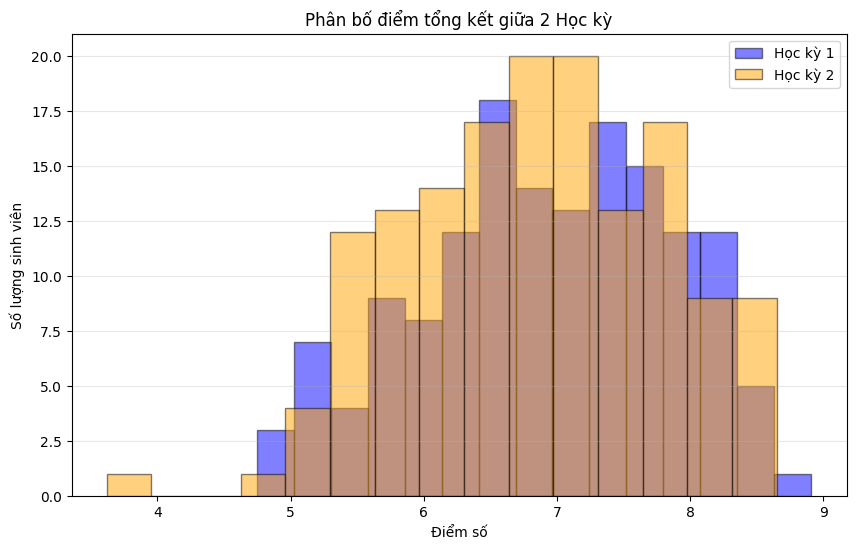

In [45]:
plt.figure(figsize=(10, 6))
plt.hist(total1, bins=15, alpha=0.5, label='Học kỳ 1', color='blue', edgecolor='black')
plt.hist(total2, bins=15, alpha=0.5, label='Học kỳ 2', color='orange', edgecolor='black')
plt.title('Phân bố điểm tổng kết giữa 2 Học kỳ')
plt.xlabel('Điểm số')
plt.ylabel('Số lượng sinh viên')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.savefig('bieu_do_so_sanh.png')
plt.show()